# Classical Markowitz Portfolio Optimization

This notebook implements the classical mean-variance optimization framework as a baseline for the quantum approach.

**Objective:**
$$\min_w \; q \cdot w^T \Sigma w - \mu^T w$$

**Subject to:**
- $\sum_i w_i = 1$ (fully invested)
- $w_{i,\min} \leq w_i \leq w_{i,\max}$ (per-asset weight bounds)

## 1. Load Data

In [6]:
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt

assets      = pd.read_csv('investment_dataset_full(assets).csv')
cov_df      = pd.read_csv('investment_dataset_full(covariance).csv', index_col=0)
scenarios_df = pd.read_csv('investment_dataset_full(scenarios).csv')

mu = assets['exp_return'].values
Sigma = cov_df.values.astype(float)
w_min = assets['w_min'].values.astype(float)
w_max = assets['w_max'].values.astype(float)
capital_charges = assets['capital_charge'].values
liquidity_scores = assets['liquidity'].values.astype(float)
n = len(mu)

print(f'{n} assets loaded')
print(f'Covariance matrix shape: {Sigma.shape}')
print(f'Scenarios shape: {scenarios_df.shape}')

50 assets loaded
Covariance matrix shape: (50, 50)
Scenarios shape: (1200, 50)


## 2. Solve for a Single Risk Aversion Level

We use `cvxpy` to solve the quadratic program exactly.
`q = 1` is a balanced starting point — equal weight on risk and return.

In [7]:
def solve_markowitz(q, mu, Sigma, w_min, w_max):
    """Solve the Markowitz problem for a given risk aversion q.
    Returns weights, portfolio return, and portfolio volatility.
    """
    w = cp.Variable(len(mu))

    risk = cp.quad_form(w, Sigma)
    ret = mu @ w
    objective = cp.Minimize(q * risk - ret)

    constraints = [
        cp.sum(w) == 1,
        w >= w_min,
        w <= w_max,
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve()

    weights = w.value
    port_return = float(mu @ weights)
    port_vol = float(np.sqrt(weights @ Sigma @ weights))
    return weights, port_return, port_vol


q = 1.0
weights, port_return, port_vol = solve_markowitz(q, mu, Sigma, w_min, w_max)

print(f'Portfolio return:     {port_return*100:.2f}%')
print(f'Portfolio volatility: {port_vol*100:.2f}%')
print(f'Sharpe (approx):      {port_return/port_vol:.3f}')

Portfolio return:     8.06%
Portfolio volatility: 9.10%
Sharpe (approx):      0.886


## 3. Top Holdings

Assets with non-trivial weight (> 0.1%) in the optimised portfolio.

In [8]:
allocation = pd.DataFrame({
    'asset_id': assets['asset_id'],
    'sector': assets['sector'],
    'weight': weights,
    'exp_return': mu,
    'volatility': assets['volatility'],
    'capital_charge': assets['capital_charge'],
}).query('weight > 0.001').sort_values('weight', ascending=False)

print(f'{len(allocation)} assets selected (weight > 0.1%)')
print(allocation.to_string(index=False, float_format='{:.4f}'.format))

20 assets selected (weight > 0.1%)
asset_id        sector  weight  exp_return  volatility  capital_charge
    A001 Equities Intl  0.0800      0.0845      0.1993          0.3500
    A016 Equities Intl  0.0800      0.0879      0.2016          0.3500
    A005 Equities Intl  0.0800      0.0860      0.1956          0.3500
    A030   Equities US  0.0800      0.0803      0.1760          0.3500
    A004   Equities US  0.0800      0.0823      0.1729          0.3500
    A023 Equities Intl  0.0757      0.0835      0.2017          0.3500
    A049   Equities US  0.0716      0.0807      0.1759          0.3500
    A013     HY Credit  0.0600      0.0732      0.1203          0.0700
    A006     HY Credit  0.0600      0.0737      0.1205          0.0700
    A037     HY Credit  0.0600      0.0743      0.1186          0.0700
    A047     HY Credit  0.0600      0.0730      0.1132          0.0700
    A025 Equities Intl  0.0503      0.0842      0.1905          0.3500
    A040   Equities US  0.0393      0.0800

## 4. Efficient Frontier

Sweep `q` from near 0 (return-seeking) to high (risk-averse) and trace out the efficient frontier.
Each point on the curve is an optimal portfolio for a different risk appetite.

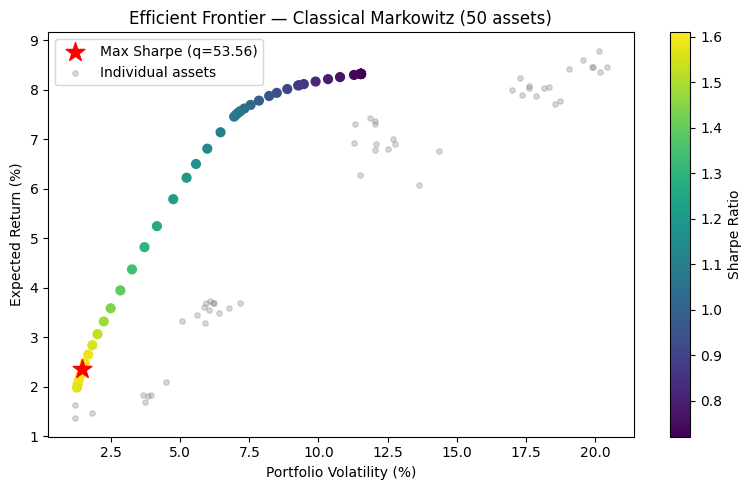

Max Sharpe: return=2.35%, vol=1.46%, Sharpe=1.609


In [ ]:
q_values = np.logspace(-2, 2, 60)   # 0.01 to 100, log-spaced

frontier_returns = []
frontier_vols = []
frontier_weights = []

for q in q_values:
    w, r, v = solve_markowitz(q, mu, Sigma, w_min, w_max)
    frontier_returns.append(r)
    frontier_vols.append(v)
    frontier_weights.append(w)

frontier_returns = np.array(frontier_returns)
frontier_vols = np.array(frontier_vols)
sharpes = frontier_returns / frontier_vols
best_idx = np.argmax(sharpes)

# fig, ax = plt.subplots(figsize=(8, 5))
# scatter = ax.scatter(
#     frontier_vols * 100, frontier_returns * 100,
#     c=sharpes, cmap='viridis', s=40, zorder=3
# )
# plt.colorbar(scatter, ax=ax, label='Sharpe Ratio')
# ax.scatter(
#     frontier_vols[best_idx] * 100, frontier_returns[best_idx] * 100,
#     marker='*', s=200, color='red', zorder=5,
#     label=f'Max Sharpe (q={q_values[best_idx]:.2f})'
# )
# ax.scatter(
#     assets['volatility'] * 100, assets['exp_return'] * 100,
#     alpha=0.3, s=15, color='grey', label='Individual assets'
# )
# ax.set_xlabel('Portfolio Volatility (%)')
# ax.set_ylabel('Expected Return (%)')
# ax.set_title('Efficient Frontier — Classical Markowitz (50 assets)')
# ax.legend()
# plt.tight_layout()
# plt.show()

# print(f'Max Sharpe: return={frontier_returns[best_idx]*100:.2f}%, vol={frontier_vols[best_idx]*100:.2f}%, Sharpe={sharpes[best_idx]:.3f}')

## 5. Classical Binary Baseline (8 Assets)

To compare directly against the quantum approach, we:
1. **Select 8 representative assets** — one per sector, chosen by highest Sharpe ratio (return / volatility)
2. **Brute-force all 2^8 = 256 binary portfolios** — each asset is either included (1) or excluded (0)
3. **Equal-weight the selected assets** — if 3 assets are chosen, each gets 1/3 of the budget

This gives the exact optimal binary solution that our quantum solution will try to match.

In [10]:
from itertools import product

# --- Step 1: Pick one asset per sector (first occurrence in dataset) ---
rep_assets = assets.groupby('sector').first().reset_index()
rep_ids = [assets.index[assets['asset_id'] == aid].item() for aid in rep_assets['asset_id']]

# Extract 8-asset versions of mu and Sigma
mu_8 = mu[rep_ids]
Sigma_8 = Sigma[np.ix_(rep_ids, rep_ids)]

print("8 representative assets (one per sector, first in dataset):")
print(rep_assets[['asset_id', 'sector', 'exp_return', 'volatility']].to_string(index=False, float_format='{:.4f}'.format))

# --- Step 2: Brute-force all 256 binary portfolios ---
results = []

for bits in product([0, 1], repeat=8):
    w = np.array(bits, dtype=float)
    k = w.sum()
    if k == 0:
        continue

    w_eq = w / k  # equal-weight the selected assets

    port_return = mu_8 @ w_eq
    port_risk   = w_eq @ Sigma_8 @ w_eq
    port_vol    = np.sqrt(port_risk)

    for q in [0.5, 1.0, 2.0, 5.0, 10.0]:
        results.append({
            'bits': bits,
            'k': int(k),
            'q': q,
            'objective': q * port_risk - port_return,
            'return': port_return,
            'volatility': port_vol,
            'sharpe': port_return / port_vol if port_vol > 0 else 0,
        })

results_df = pd.DataFrame(results)

# --- Step 3: Best portfolio at each q ---
print("\nBest binary portfolio at each risk aversion level:")
print("-" * 80)
for q in [0.5, 1.0, 2.0, 5.0, 10.0]:
    subset  = results_df[results_df['q'] == q]
    best    = subset.loc[subset['objective'].idxmin()]
    assets_selected = [rep_assets.iloc[i]['asset_id'] for i, b in enumerate(best['bits']) if b == 1]
    print(f"q={q:>5.1f}: return={best['return']*100:.2f}%  vol={best['volatility']*100:.2f}%  "
          f"Sharpe={best['sharpe']:.3f}  k={best['k']:.0f}")
    print(f"         Assets: {', '.join(assets_selected)}")

# --- Overall max-Sharpe binary portfolio ---
best_row         = results_df.loc[results_df['sharpe'].idxmax()]
best_binary_bits = best_row['bits']
assets_selected  = [rep_assets.iloc[i]['asset_id'] for i, b in enumerate(best_binary_bits) if b == 1]
print(f"\nMax Sharpe binary portfolio:")
print(f"  Return={best_row['return']*100:.2f}%, Vol={best_row['volatility']*100:.2f}%, Sharpe={best_row['sharpe']:.3f}")
print(f"  Selected ({int(best_row['k'])}): {', '.join(assets_selected)}")

8 representative assets (one per sector, first in dataset):
asset_id         sector  exp_return  volatility
    A007           Cash      0.0164      0.0121
    A001  Equities Intl      0.0845      0.1993
    A004    Equities US      0.0823      0.1729
    A014      Gov Bonds      0.0184      0.0393
    A006      HY Credit      0.0737      0.1205
    A002      IG Credit      0.0345      0.0561
    A038 Infrastructure      0.0629      0.1148
    A022    Real Estate      0.0607      0.1362

Best binary portfolio at each risk aversion level:
--------------------------------------------------------------------------------
q=  0.5: return=8.02%  vol=10.30%  Sharpe=0.779  k=3
         Assets: A001, A004, A006
q=  1.0: return=8.02%  vol=10.30%  Sharpe=0.779  k=3
         Assets: A001, A004, A006
q=  2.0: return=7.59%  vol=8.60%  Sharpe=0.882  k=4
         Assets: A001, A004, A006, A038
q=  5.0: return=6.64%  vol=6.90%  Sharpe=0.963  k=6
         Assets: A001, A004, A006, A002, A038, A022
q= 10